# Частина перша: Знайомство з Pandas.

In [2]:
from io import StringIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

In [3]:
"""
This returns: 403 Forbidden. Must be the protection from bots.
We're going to pretend we're a browser
"""
url = "https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8"
# fertility_table = pd.read_html(
#             url,
#             attrs={"id": "collapsibleTable4"},
# )

In [ ]:
# Pretending we're a browser (notes for myself: this is such a mess, NEVER use pandas' read_html EVER again, just go with beautiful soup, in the worst case with Selenium)
header = {
  "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/50.0.2661.75 Safari/537.36",
}

response = requests.get(url, headers=header, timeout=5000)
# Wrap the text in StringIO so Pandas treats it like a file
html_stream = StringIO(response.text)
# returns a list of dataframes so we take the first element
fertility_table = pd.read_html(
    html_stream,
    match="Коефіцієнт народжуваності в регіонах України",
    # attrs={"id": "collapsibleTable4"},                  # using IDs is a bad idea for Wiki, they may be dynamic
    decimal=",",   # Recognizes 13,0 as 13.0 (European-style uses commas, but Python expects dots)
    thousands=".",  # Handles any dot-based grouping if present
)[0]

##### Вивести перші рядки таблиці за допомогою методу head

In [5]:
fertility_table.head()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,—,—
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,—


##### Визначте кількість рядків та стовпців у датафреймі (атрибут shape)

In [6]:
fertility_table.shape

(28, 9)

##### Замініть у таблиці значення "—" на значення NaN

In [7]:
fertility_table = fertility_table.replace("—", np.nan)
fertility_table.head()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,NaN,NaN
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,NaN


##### Визначте типи всіх стовпців за допомогою dataframe.dtypes

In [8]:
fertility_table.dtypes

Регіон        str
1950      float64
1960      float64
1970      float64
1990      float64
2000      float64
2012      float64
2014          str
2019          str
dtype: object

##### Замініть типи нечислових колонок на числові. Підказка - це колонки, де знаходився символ "—"

In [9]:
str_cols_to_num = ["2014", "2019"]

for col in str_cols_to_num:
    fertility_table[col] = pd.to_numeric(fertility_table[col])

fertility_table.dtypes

Регіон        str
1950      float64
1960      float64
1970      float64
1990      float64
2000      float64
2012      float64
2014      float64
2019      float64
dtype: object

##### Порахуйте, яка частка пропусків міститься в кожній колонці (використовуйте методи isnull та sum)

In [10]:
fertility_table.isna().sum() / len(fertility_table)

Регіон    0.000000
1950      0.071429
1960      0.035714
1970      0.035714
1990      0.000000
2000      0.000000
2012      0.000000
2014      0.071429
2019      0.142857
dtype: float64

##### Видаліть з таблиці дані по всій країні, останній рядок таблиці

In [11]:
# The task isn't clear. Assuming "Видаліть з таблиці 'дані по всій країні' останній рядок таблиці"
print(f"len(df) = {len(fertility_table)}")
fertility_table = fertility_table.iloc[:-1]
print(f"len(df) = {len(fertility_table)}")

len(df) = 28
len(df) = 27


##### Замініть відсутні дані в стовпцях середніми значеннями цих стовпців (метод fillna)

In [12]:
fertility_table = fertility_table.fillna(fertility_table.mean(numeric_only=True))
fertility_table.head()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,11.144,8.017391
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.900,7.600000
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.100,10.100000
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.100,7.100000
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.200,8.017391


##### Отримайте список регіонів, де рівень народжуваності у 2019 році був вищим за середній по Україні

In [13]:
fertility_table[fertility_table["2019"] > fertility_table["2019"].mean()]["Регіон"]

2             Волинська
6          Закарпатська
8     Івано-Франківська
12            Львівська
14              Одеська
16           Рівненська
20           Херсонська
23          Чернівецька
25                 Київ
Name: Регіон, dtype: str

##### У якому регіоні була найвища народжуваність у 2014 році?

In [14]:
fertility_table[fertility_table["2014"] == fertility_table["2014"].max()][["Регіон", "2014"]]

,Регіон,2014
16,Рівненська,14.8


##### Побудуйте стовпчикову діаграму народжуваності по регіонах у 2019 році

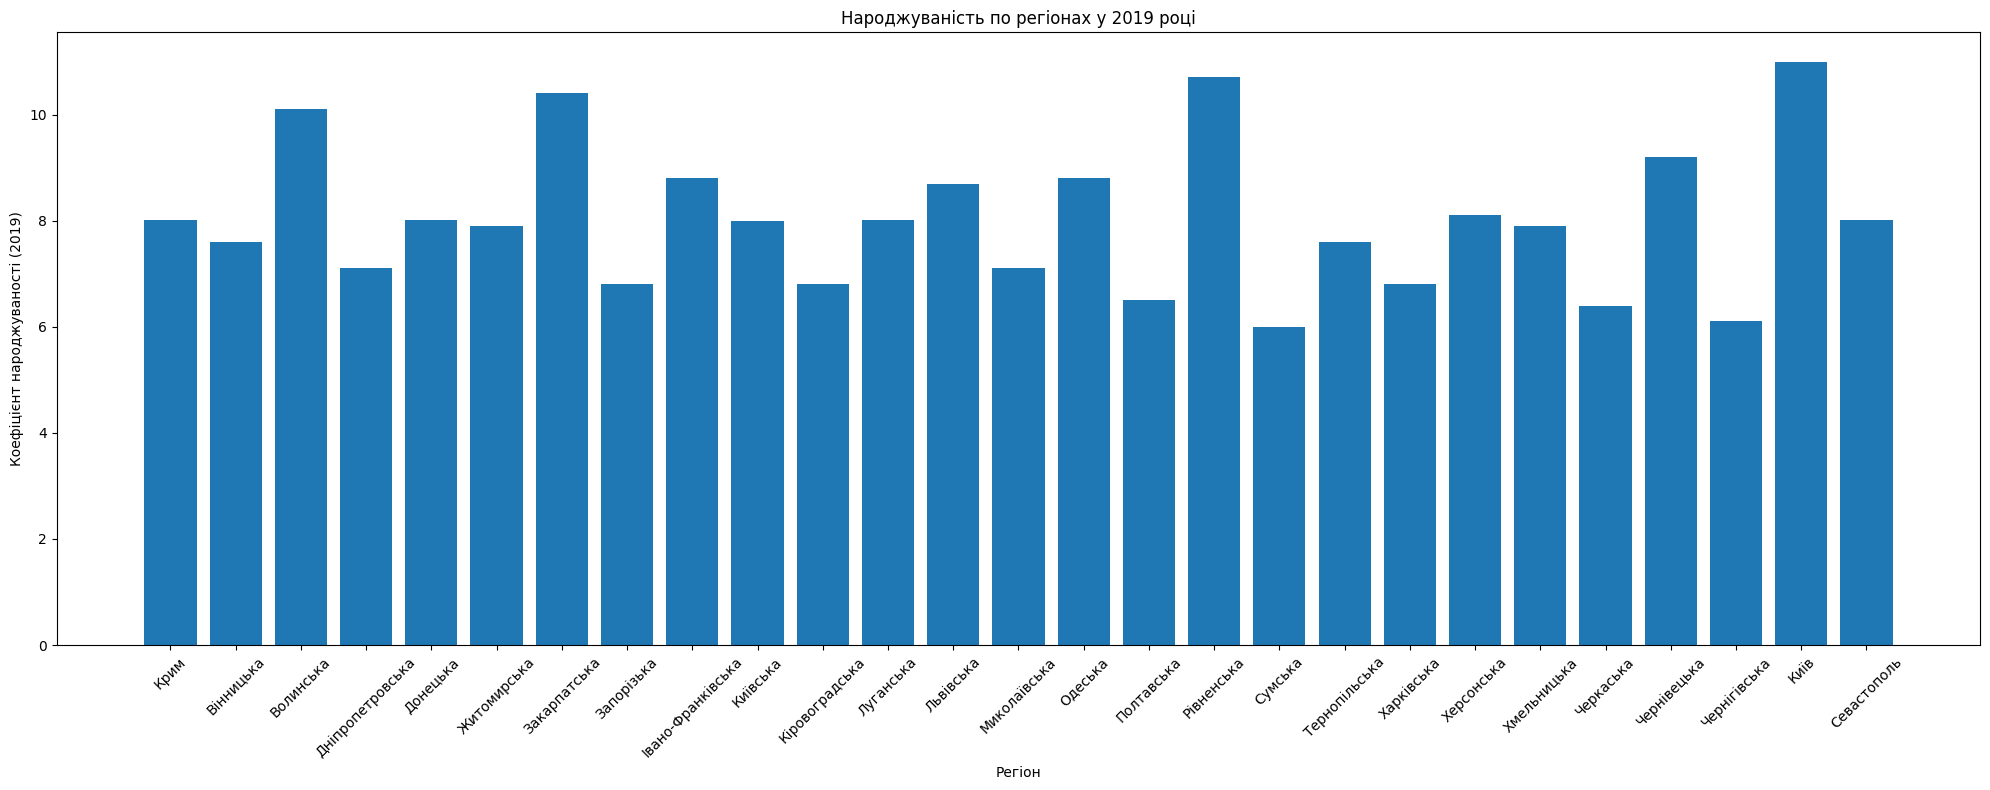

In [15]:
plt.figure(figsize=(20, 8))
plt.bar(fertility_table["Регіон"], fertility_table["2019"])
plt.xlabel("Регіон")
plt.ylabel("Коефіцієнт народжуваності (2019)")
plt.title("Народжуваність по регіонах у 2019 році")
plt.xticks(rotation=45)  # Rotate labels to make them readable
plt.tight_layout() # automatically adjust text label and title spacing
plt.show()

## Додайте від 3 до 5 графіків функцій різного типу на ваш вибір. Задайте графікам оформлення, щоб кожен графік у своїй домашній роботі чимось відрізнявся і не був схожим на інші. Можна використовувати як matplotlib, так і seaborn.

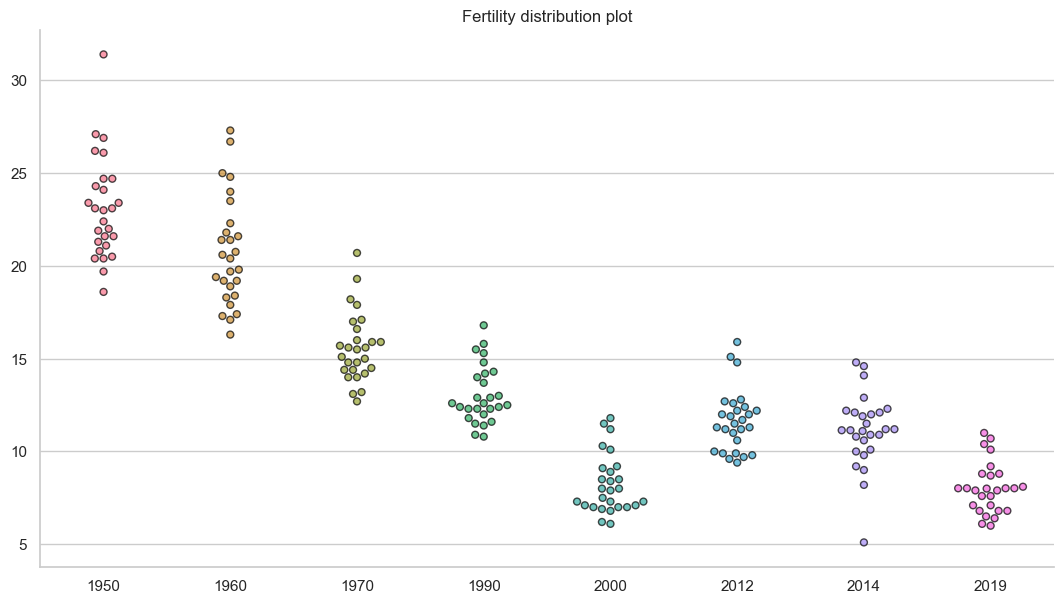

In [85]:
sns.set_theme(style="whitegrid", palette="ch:s=-.2,r=.6", font="sans-serif")
g = sns.catplot(data=fertility_table,
                kind="swarm",
                height=6,
                aspect=1.8,
                s=25,
                linewidth=1,   # Outline around dots
                alpha=0.7,
                edgecolor="black",
)           # Point size)
g.set(title="Fertility distribution plot")
plt.show()

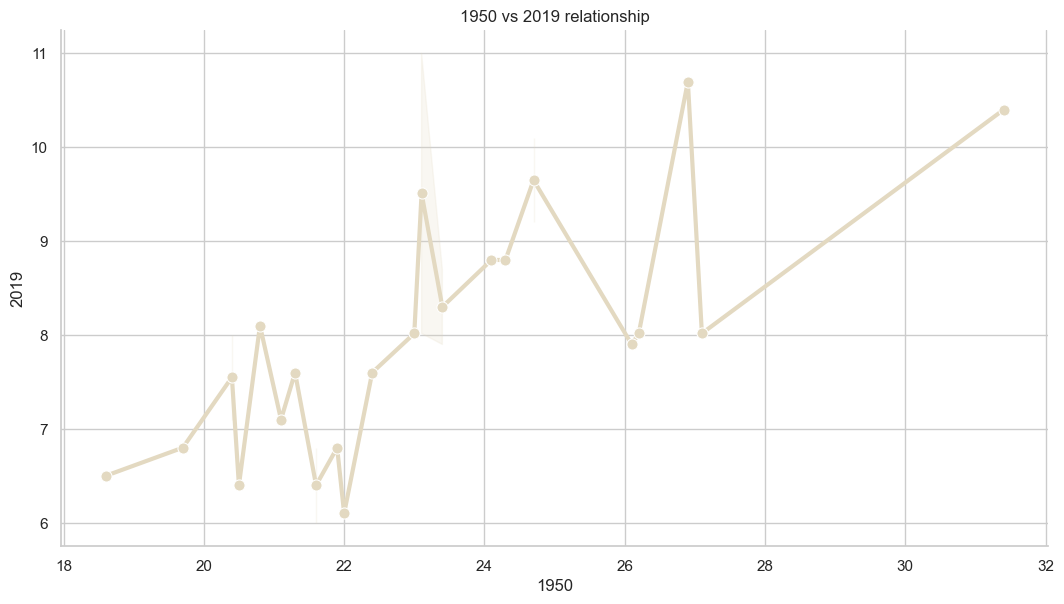

In [88]:
g= sns.relplot( data=fertility_table,
                x="1950",
                y="2019",
                kind="line",
                linewidth=3,    # Thicker line looks more professional
                marker="o",     # Adds dots at the data points
                markersize=8,
                height=6,
                aspect=1.8,
)
g.set(title="1950 vs 2019 relationship")
plt.show()

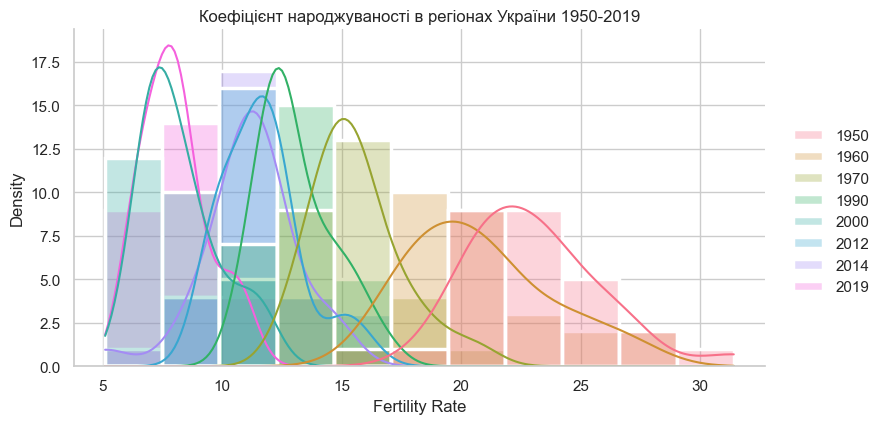

In [ ]:
g = sns.displot(
    data=fertility_table,
    kde=True,             # The smooth line
    fill=True,            # Shaded area under the curve
    alpha=0.3,            # Makes the shading soft/transparent
    color="teal",         # A professional, calming color
    linewidth=2.5,        # Thicker KDE line
    aspect=2.0,           # Makes it wide and cinematic
    height=4,
)

g.set(title="Коефіцієнт народжуваності в регіонах України 1950-2019")
g.set_axis_labels("Fertility Rate", "Density")
plt.show()